In [230]:
from nilearn import image
from pathlib import Path
from nilearn import plotting
import pandas as pd
from nilearn.reporting import get_clusters_table
import numpy as np

/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/image/image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


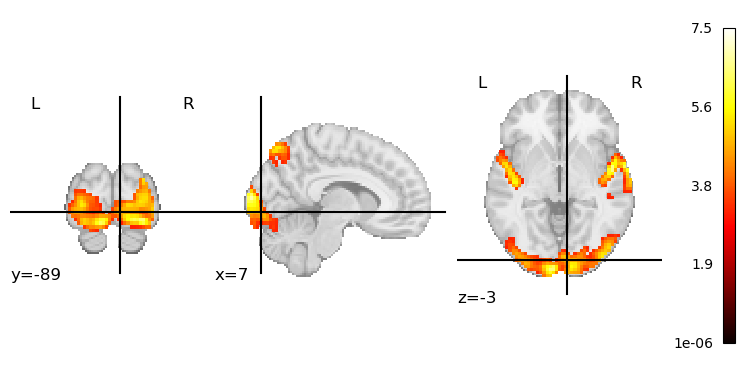

In [232]:
base_dir = Path('/data/ds-mlearn/nipype/model2')
thr = 3.1

choice_contrast = base_dir / '2ndLevel' / 'cluster_SnPM_SecondLevel_con17' / 'SnPM_filtered_t3_1_pos.nii'

choice_contrast = image.load_img(choice_contrast)
plotting.plot_stat_map(choice_contrast, cmap='hot')

df, clusters = get_clusters_table(choice_contrast, stat_threshold=4.0, return_label_maps=True)
clusters = clusters[0]

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 83
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = [0.0002, 0.0026, 0.0026, 0.0008, 0.498]
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con17_3_1_pos.csv')

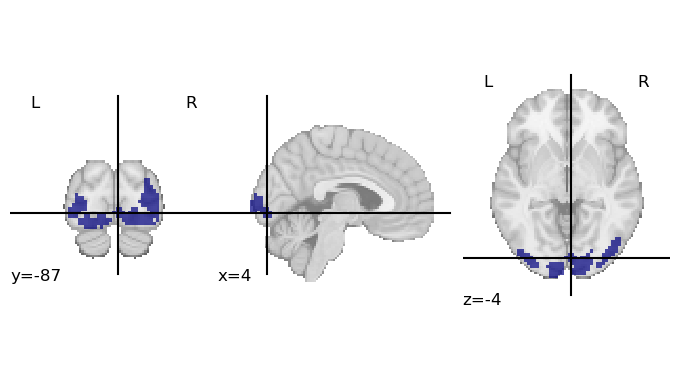

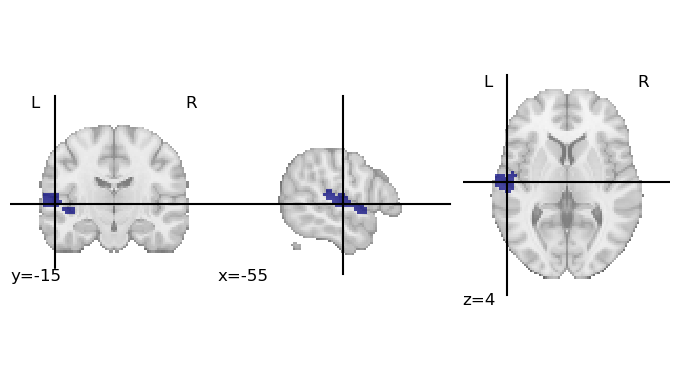

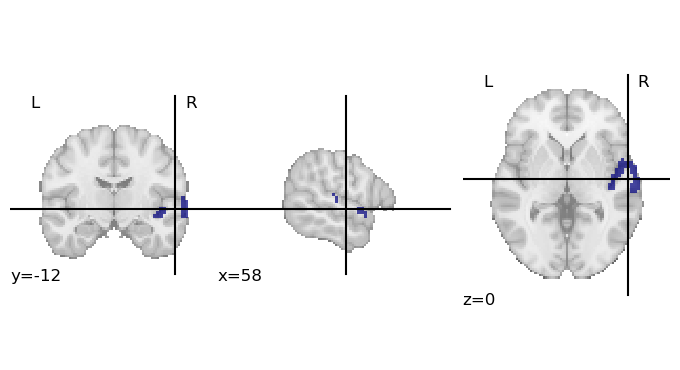

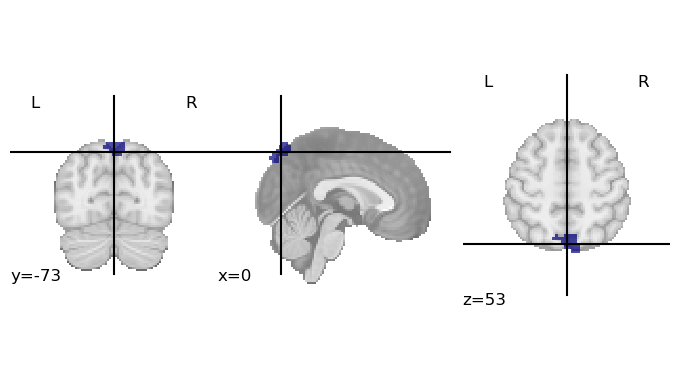

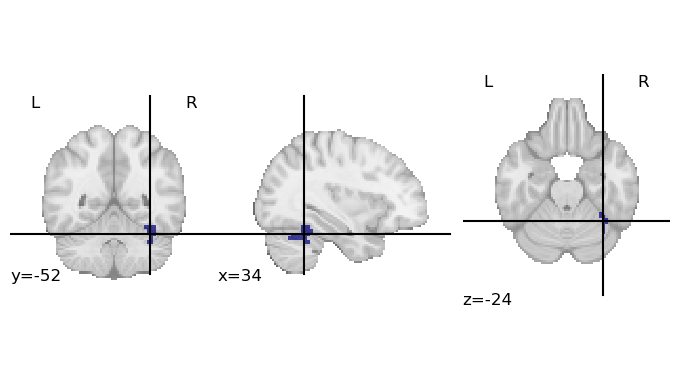

In [233]:
for i, cluster in enumerate(df['Cluster Index'].unique()):

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c)

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con17_3_1_pos.nii'

    c.to_filename(target_fn)

# Tactile > auditory

/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/image/image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


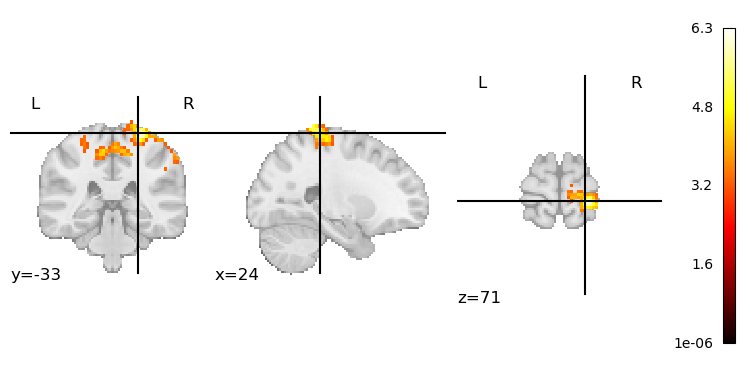

In [237]:
base_dir = Path('/data/ds-mlearn/nipype/model2')
thr = 3.1

choice_contrast = base_dir / '2ndLevel' / 'cluster_SnPM_SecondLevel_con17' / 'SnPM_filtered_t3_1_neg.nii'

choice_contrast = image.load_img(choice_contrast)
plotting.plot_stat_map(choice_contrast, cmap='hot')

df, clusters = get_clusters_table(choice_contrast, stat_threshold=4.0, return_label_maps=True)
clusters = clusters[0]

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 83
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
# df['P_FWE_corr'] = [0.0002, 0.0026, 0.0026, 0.0008, 0.498]
# df.to_csv(base_dir / 'ROI' / 'snpm_stats_con17_3_1_neg.csv')

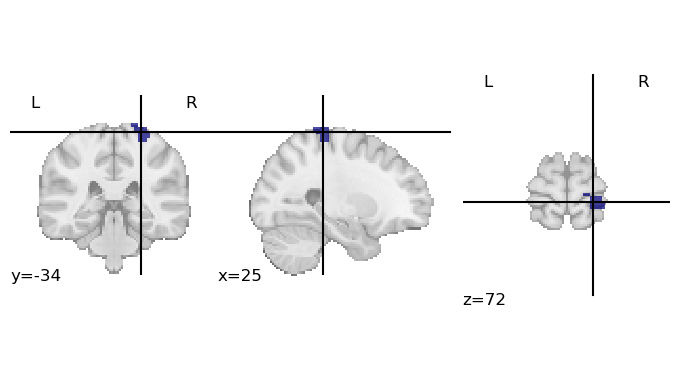

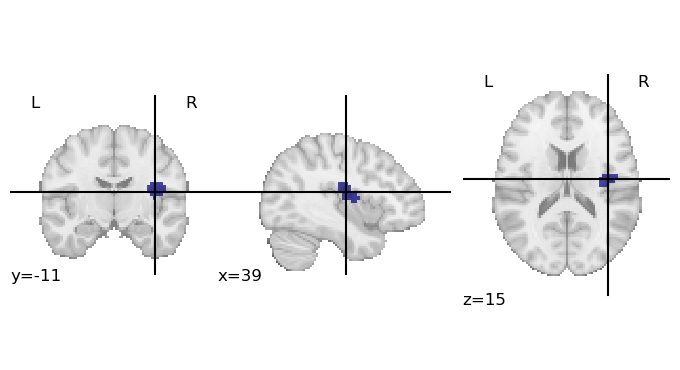

In [238]:
for i, cluster in enumerate(df['Cluster Index'].unique()):

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c)

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con17_3_1_neg.nii'

    c.to_filename(target_fn)